## Logistic Regression

Logistic Regression is a supervised machine learning algorithm that can be used for binary classification.

For this project:
- `X` has the SMART features used as inputs.
- `y` has the correct labels.
- `0` means the drive does not fail within 30 days.
- `1` means the drive fails within 30 days.

During training, the model receives `X_train` and `y_train`. It uses the features and known answers to learn a relationship that can be used later to make predictions on unseen data.

### Weights and Bias

Logistic Regression learns a weight for each input feature and one bias value.

The model first calculates a score: z = wᵀx + b (z = (w₁ × x₁) + (w₂ × x₂) + ... + (wₙ × xₙ) + b)

Where:
- `x` = the input feature values for one observation
- `w` = the weights learned for each feature
- `b` = the bias learned by the model
- `z` = the resulting score

A positive weight means that increasing that feature pushes the score more toward class 1, while a negative weight pushes it more toward class 0. A weight closer to 0 has less effect on the score. The bias is an additional value added to the score. It gives the model a starting offset instead of forcing the score to be 0 when all feature values are 0.

### How the Model Learns

The model does not understand the data like a person would so the training is a mathematical optimization process.

During `.fit(X_train, y_train)`, the model:
1. Makes predictions using its current weights and bias.
2. Compares those predictions with the correct values in `y_train`.
3. Calculates how wrong the predictions are using a loss function.
4. Adjusts the weights and bias to reduce the loss.
5. Repeats this process to find better values.

The final learned weights and bias are the values that the training algorithm found to work well for predicting the training labels.

### Sigmoid

The score `z` is not a probability. Logistic Regression passes it through the sigmoid function: sigmoid(z) = 1 / (1 + e^(-z))

The sigmoid converts any score into a value between 0 and 1.

For example:
- A large negative score produces a probability close to 0.
- A score of 0 produces a probability of 0.5.
- A large positive score produces a probability close to 1.

This gives the predicted probability of class 1. For this project, class 1 means failure within 30 days.

### Full Prediction Process

The overall process is:

1. SMART features
2. Preprocessing 
3. Z-scores for the features 
4. Multiply each feature by its learned weight 
5. Add the results and the bias 
6. z = wᵀx + b 
7. Apply sigmoid 
8. Probability between 0 and 1 
9. Class prediction (0 or 1)

In [28]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import json

training_df = pd.read_csv("../data/processed/training_data.csv")

with open("../data/processed/selected_features.json", "r") as file:
    selected_features = json.load(file)

training_df["date"] = pd.to_datetime(training_df["date"])
training_df = training_df.sort_values("date").reset_index(drop=True)

usable_df = training_df[training_df["date"] <= pd.Timestamp("2026-03-01")].copy()

train_end = pd.Timestamp("2026-02-09")
val_end = pd.Timestamp("2026-02-19")
train_mask = usable_df["date"] <= train_end
val_mask = ((usable_df["date"] > train_end) & (usable_df["date"] <= val_end))
test_mask = usable_df["date"] > val_end

X_train = usable_df.loc[train_mask, selected_features]
X_val = usable_df.loc[val_mask, selected_features]
X_test = usable_df.loc[test_mask, selected_features]

y_train = usable_df.loc[train_mask, "failure_within_30_days"]
y_val = usable_df.loc[val_mask, "failure_within_30_days"]
y_test = usable_df.loc[test_mask, "failure_within_30_days"]

scaled_preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("scaler", StandardScaler())])

In [29]:
logistic_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
logistic_pipeline.fit(X_train, y_train)
validation_predictions = logistic_pipeline.predict(X_val)

validation_probabilities = logistic_pipeline.predict_proba(X_val)

failure_probabilities = validation_probabilities[:,1]
print(failure_probabilities[:10])

[1.26851652e-01 1.75619672e-01 1.54714443e-01 8.19505374e-13
 1.48801895e-01 1.22543028e-01 1.85626290e-01 1.23020264e-01
 5.75913986e-02 1.68049151e-01]


In [30]:
prediction_check = pd.DataFrame({"actual": y_val.iloc[:10].values, "predicted": validation_predictions[:10], "failure_probability": failure_probabilities[:10]})
logistic_model = logistic_pipeline.named_steps["model"]

print(prediction_check)

print("Weights:")
print(logistic_model.coef_)

print("Bias:")
print(logistic_model.intercept_)

   actual  predicted  failure_probability
0       0          0         1.268517e-01
1       0          0         1.756197e-01
2       0          0         1.547144e-01
3       0          0         8.195054e-13
4       0          0         1.488019e-01
5       0          0         1.225430e-01
6       0          0         1.856263e-01
7       0          0         1.230203e-01
8       0          0         5.759140e-02
9       0          0         1.680492e-01
Weights:
[[-0.50783983  0.13601306  0.21242475  0.31819426  2.81738516 -0.02816743
  -0.21416805  0.07392434 -0.19235609  0.5564055  -0.06812246 -0.01830954
  -0.02959406 -0.25986901  0.21076393  0.22181104  0.14241131  0.2643643
   0.14865151  0.32544493  0.11119143 -0.06676586  3.96391926 -0.2228259
  -3.93065888 -0.36915954 -1.56491354  0.20037102  0.20037102 -0.39219306
  -0.39219306 -0.39219306 -0.39219306  0.13346253  0.13346253 -0.39219306
  -0.39219306  0.31003371  0.31003371 -0.07937742  0.31003371  0.31003371
  -0.40023334

### Conclusion

In this task, I trained my first machine learning baseline using Logistic Regression. The model was trained using `X_train` and `y_train`, where the features were first processed using median imputation and standardization.

During `.fit()`, the preprocessing steps learned the training medians, means, and standard deviations. Logistic Regression then used the processed features and known training labels to learn weights for the features and a bias.

The model uses the weights and feature values to calculate a score: z = wᵀx + b

The sigmoid function converts this score into a probability between 0 and 1. This probability represents the model's predicted probability of failure within 30 days. I used `.predict()` to generate class predictions of 0 or 1 and `.predict_proba()` to get the probability of each class. I also inspected the learned coefficients and bias from the trained model. This Logistic Regression model will be used to compare against other models later.

In [37]:
from sklearn.metrics import confusion_matrix

# Compares what actually happened against what the model predicted
# Output: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_val, validation_predictions).ravel()

# Out of everything the model predicted, how often is it correct?
# 78.86% of all the predictions were correct
accuracy = (tn + tp)/(tn + tp + fn + fp)

# When the model warns about failure, how often is it correct?
# 78.6% of the model's failure warnings were correct
precision = tp/(tp + fp)

# Of all the failures that happened, how many did the model catch? 
# 6.88% of the model's failures were caught
recall = tp/(tp + fn)

# F1-score combines precision and recall into one measurement and is useful when both are important
f1 = 2 * ((precision * recall)/(precision + recall))

print(accuracy, precision, recall, f1)



0.7885628291948834 0.7859649122807018 0.06883835279655809 0.12658943204294998


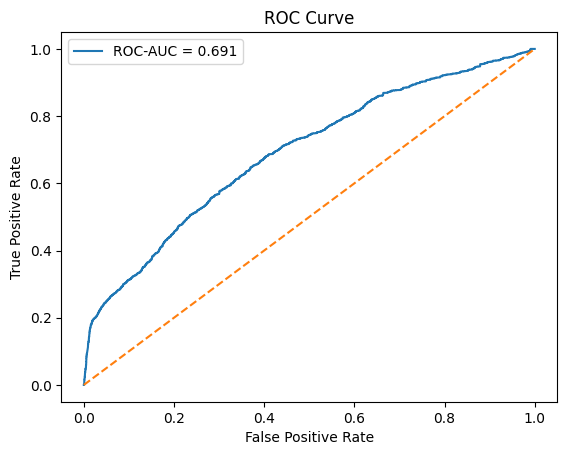

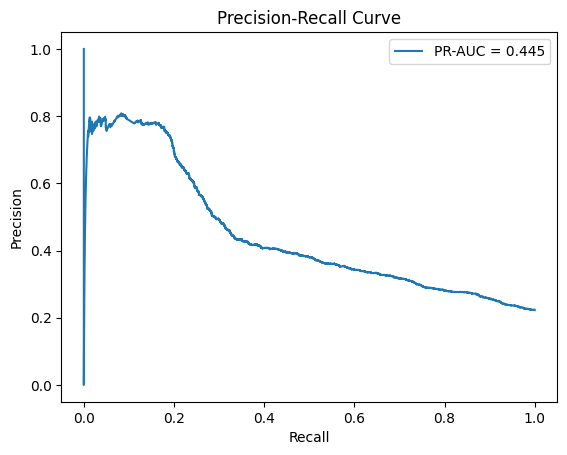

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# ROC-AUC evaluates the model without committing to one threshold
# Tests the model across different thresholds and looks at the tradeoff between True Positive Rate and False Positive Rate
roc_auc = roc_auc_score(y_val,failure_probabilities)

# Tests the model across different thresholds and looks at the tradeoff between precision and recall
pr_auc = average_precision_score(y_val, failure_probabilities)

fpr, tpr, thresholds = roc_curve(y_val, failure_probabilities)
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_val, failure_probabilities)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

plt.plot(recall_values, precision_values, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [43]:
thresholds_to_test = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds_to_test: 
  threshold_predictions = (failure_probabilities >= threshold).astype(int)

  tn, fp, fn, tp = confusion_matrix(y_val, threshold_predictions).ravel()

  precision = tp/(tp + fp)
  recall = tp/(tp + fn)
  f1 = 2 * ((precision * recall)/(precision + recall))

  print(precision, recall, f1)

0.7859649122807018 0.06883835279655809 0.12658943204294998
0.8010899182561307 0.09035033804548248 0.16238608119304057
0.775974025974026 0.14689612784265518 0.2470284237726098
0.4743470149253731 0.31253841425937307 0.3768062245276028
0.23119347010809618 0.9661954517516902 0.37310864534504246


In [44]:
majority_predictions = [0] * len(y_val)
majority_accuracy = (y_val == majority_predictions).mean()

print("Majority baseline accuracy:", majority_accuracy)
print("Logistic Regression accuracy:", accuracy)

Majority baseline accuracy: 0.7774129557425269
Logistic Regression accuracy: 0.7885628291948834


### Conclusion

In this task, I learned how to evaluate a classification model instead of only looking at its accuracy. I first used a confusion matrix to see the true positives, true negatives, false positives, and false negatives. The Logistic Regression model had about 78.9% accuracy and 78.6% precision, but only about 6.9% recall. This means that when the model predicted a failure it was usually correct, but it missed most of the failures that actually happened. The F1-score combines precision and recall into one value.

I also used ROC-AUC and PR-AUC to look at the model across different thresholds. ROC-AUC compares the true positive rate and false positive rate, while PR-AUC compares precision and recall. The ROC-AUC was about 0.691 and the PR-AUC was about 0.445. I then tested different thresholds. Lowering the threshold made the model predict more failures, which increased recall, but it also caused more false positives and lowered precision. This helped show that changing the threshold creates a tradeoff between precision and recall.

Finally, I compared Logistic Regression to a simple baseline that always predicts 0. The baseline still got about 77.7% accuracy, while Logistic Regression got about 78.9%. This showed me why accuracy can be misleading when one class appears much more often than the other.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 5, 10, None]

for depth in depths: 
  tree_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("model", DecisionTreeClassifier(max_depth=depth, random_state=44))])
  tree_pipeline.fit(X_train, y_train)

  train_predictions = tree_pipeline.predict(X_train) 
  val_predictions = tree_pipeline.predict(X_val)

  train_accuracy = accuracy_score(y_train, train_predictions)
  val_accuracy = accuracy_score(y_val, val_predictions)

  
  print(f"Depth: {depth} | Train Accuracy: {train_accuracy:.3f} | Validation Accuracy: {val_accuracy:.3f}")


Depth: 2 | Train Accuracy: 0.828 | Validation Accuracy: 0.777
Depth: 3 | Train Accuracy: 0.839 | Validation Accuracy: 0.788
Depth: 5 | Train Accuracy: 0.848 | Validation Accuracy: 0.788
Depth: 10 | Train Accuracy: 0.893 | Validation Accuracy: 0.815
Depth: None | Train Accuracy: 0.999 | Validation Accuracy: 0.893


### Conclusion

In this task, I learned how Decision Trees can be used for classification. A Decision Tree makes predictions by splitting the data using different feature values until it reaches a leaf with a final prediction.

I tested different `max_depth` values to see how the depth affects the model. As the depth increased, the tree was able to learn more detailed patterns and the training accuracy increased. The unrestricted tree reached almost 100% training accuracy, showing that a very deep tree can start fitting the training data very closely. This can lead to overfitting if the patterns it learns do not work as well on new data.

I also learned about underfitting and overfitting. A tree that is too shallow may be too simple to learn enough patterns, while a tree that is too deep can learn patterns that are too specific to the training data. Comparing training and validation performance helps show whether this is happening.

Finally, I learned that Gini impurity measures how mixed the classes are at a node. A lower Gini impurity means the node contains more examples from one class. The Decision Tree uses this to find useful splits that better separate the classes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("model", RandomForestClassifier(random_state=44))])
random_forest_pipeline.fit(X_train, y_train)